
# **Part 1: Import & Preprocessing**

This notebook analyzes the Superstore Sales dataset to understand sales performance, profitability, product performance, and regional trends. The analysis follows a structured pipeline: preprocessing, feature engineering, exploratory data analysis with visualizations, business insights, and conclusions.

## 1.1 Import Libraries

This section imports all necessary Python libraries for data manipulation, visualization, and analysis and sets display options for better readability. It also performs an initial inspection of the data by showing the first 3 rows.

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.ticker as ticker
from IPython.display import display

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Display options for cleaner output
pd.options.display.max_columns = None
pd.options.display.float_format = '{:.2f}'.format

## 1.2 Load Dataset

The dataset is loaded from a CSV file. /Sample-Superstore2019.csv


In [121]:
df = pd.read_csv('/Sample-Superstore2019.csv')
df.head(3)


,Unnamed: 0,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.00,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.00,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.00,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87


This cell displays the current column names of the DataFrame.

In [122]:
df.columns

Index(['Unnamed: 0', 'Row ID', 'Order ID', 'Order Date', 'Ship Date',
       'Ship Mode', 'Customer ID', 'Customer Name', 'Segment',
       'Country/Region', 'City', 'State', 'Postal Code', 'Region',
       'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales',
       'Quantity', 'Discount', 'Profit'],
      dtype='object')

This cell defines two helper functions:
- `check_missing_values(df)`: Prints the count of missing values for each column.
- `check_duplicates(df)`: Prints the number of duplicate rows in the DataFrame.

## 1.3 Check for Missing Values

Missing values can skew analysis results. This step identifies if any columns contain null values.

In [123]:
def check_missing_values(df):
    print("Missing Values per Column:")
    print(df.isnull().sum())

## 1.4 Check for Duplicate Records

Duplicate rows can inflate counts and distort aggregations. This step detects any exact duplicate records.

In [124]:
def check_duplicates(df):
    print("Number of Duplicate Rows:")
    print(df.duplicated().sum())

This cell calls the previously defined functions to check for missing values and duplicate rows in the DataFrame `df`.

In [125]:
check_missing_values(df)
check_duplicates(df)

Missing Values per Column:
Unnamed: 0         0
Row ID             0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64
Number of Duplicate Rows:
0


## 1.5 Remove Unnecessary Columns

Columns that do not contribute to the analysis (e.g., identifiers, redundant location data) are removed to reduce noise and improve performance.

In [126]:
def drop_columns(df, columns):
    df = df.drop(columns=columns)
    return df

In [127]:
df = drop_columns(
    df,
    ['Postal Code', 'Country/Region', 'Unnamed: 0', 'Row ID']
)

## 1.6 Standardize Column Names

Consistent naming conventions (lowercase, underscores instead of spaces/hyphens) make columns easier to reference and prevent typing errors.

In [128]:
def standardize_column_names(df):
    df.columns = (
        df.columns
        .str.lower()
        .str.replace(' ', '_')
        .str.replace('-', '_')
    )
    return df

## 1.7 Convert Columns to Appropriate Data Types

Converting date columns to datetime enables time-based analysis. Converting categorical columns to 'category' dtype reduces memory usage and improves performance.

In [129]:
df = standardize_column_names(df)
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id',
       'customer_name', 'segment', 'city', 'state', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit'],
      dtype='object')

This cell defines a function `convert_to_datetime` that takes a DataFrame and a list of column names, then converts the specified columns to datetime objects.

In [130]:
def convert_to_datetime(df, columns):
    """
    Converts specified columns to datetime objects.
    """
    for column in columns:
        df[column] = pd.to_datetime(df[column])
    return df

def convert_to_category(df, columns):
    """
    Converts specified columns to categorical data type.
    """
    for column in columns:
        df[column] = df[column].astype('category')
    return df

# Apply conversions
df = convert_to_datetime(df, ['order_date', 'ship_date'])
df = convert_to_category(
    df,
    ['ship_mode', 'segment', 'city', 'state', 'region', 'category', 'sub_category']
)

## 1.8 Preprocessing Summary

A final check confirms that all columns have the correct data types and that no missing values or duplicates remain after cleaning.

In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       9994 non-null   object        
 1   order_date     9994 non-null   datetime64[ns]
 2   ship_date      9994 non-null   datetime64[ns]
 3   ship_mode      9994 non-null   category      
 4   customer_id    9994 non-null   object        
 5   customer_name  9994 non-null   object        
 6   segment        9994 non-null   category      
 7   city           9994 non-null   category      
 8   state          9994 non-null   category      
 9   region         9994 non-null   category      
 10  product_id     9994 non-null   object        
 11  category       9994 non-null   category      
 12  sub_category   9994 non-null   category      
 13  product_name   9994 non-null   object        
 14  sales          9994 non-null   float64       
 15  quantity       9994 n

## Export and Reload Cleaned Data

After completing the preprocessing steps, the cleaned dataset is exported to Parquet format. The Parquet file is then reloaded and used as the input for the subsequent exploratory analysis, feature engineering, and visualization stages. This demonstrates the separation between the data preparation stage and the analysis stage.

In [132]:
# Export cleaned dataset as Parquet
df.to_parquet('/content/cleaned_superstore.parquet', index=False)

# **Part 2: EDA & Feature Engineering**

Before building visualizations, we engineer new features that reveal deeper business insights: unit cost, profit margin, and shipping duration.

In [133]:
# Load the cleaned dataset from Parquet
df = pd.read_parquet('/content/cleaned_superstore.parquet')
df.head()

,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,city,state,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


## 2.1 Descriptive Statistics

The `describe()` function is used to provide a statistical summary of the numerical variables in the dataset. It helps us understand the general characteristics of the data before performing feature engineering and visualization.

The summary includes the count, mean, standard deviation, minimum value, quartiles, and maximum value for each numerical variable.

This step helps identify the range and distribution of the numerical data and provides an initial understanding of variables such as Sales, Quantity, Discount, and Profit.

In [134]:
df.describe(include='number')

,sales,quantity,discount,profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


## 2.2 Create Unit Cost

Unit cost represents the cost to the business per item sold. It is derived from:  
`unit_cost = (sales - profit) / quantity`

In [135]:
df['unit_cost'] = (df['sales'] - df['profit']) / df['quantity']

## 2.3 Create Profit Margin

Profit margin shows what percentage of each sale is actual profit. It helps identify which transactions or products are most efficient at turning revenue into profit.

`profit_margin = (profit / sales) * 100`

In [136]:
df['profit_margin'] = (df['profit'] / df['sales']) * 100

## 2.4 Create Shipping Days

Shipping days measures the fulfillment speed — the number of days between the order date and the ship date. This is useful for evaluating logistics performance.

In [137]:
df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days

## 2.5 Feature Engineering Summary

Review the DataFrame structure to confirm all engineered features are correctly added.

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       9994 non-null   object        
 1   order_date     9994 non-null   datetime64[ns]
 2   ship_date      9994 non-null   datetime64[ns]
 3   ship_mode      9994 non-null   category      
 4   customer_id    9994 non-null   object        
 5   customer_name  9994 non-null   object        
 6   segment        9994 non-null   category      
 7   city           9994 non-null   category      
 8   state          9994 non-null   category      
 9   region         9994 non-null   category      
 10  product_id     9994 non-null   object        
 11  category       9994 non-null   category      
 12  sub_category   9994 non-null   category      
 13  product_name   9994 non-null   object        
 14  sales          9994 non-null   float64       
 15  quantity       9994 n

# **Part 3: Visualization & Analysis**

Each visualization follows this structure:  
**Business Question → Analytical Table/Chart → Interpretation**

---

## Visualization 1: Which States Generate the Highest Profit and the Greatest Losses?

**Business Question:** Which geographic markets are the most profitable, and which are draining revenue?

**Approach:** Aggregate total profit by state, then compare the top 5 and bottom 5 performers side-by-side.

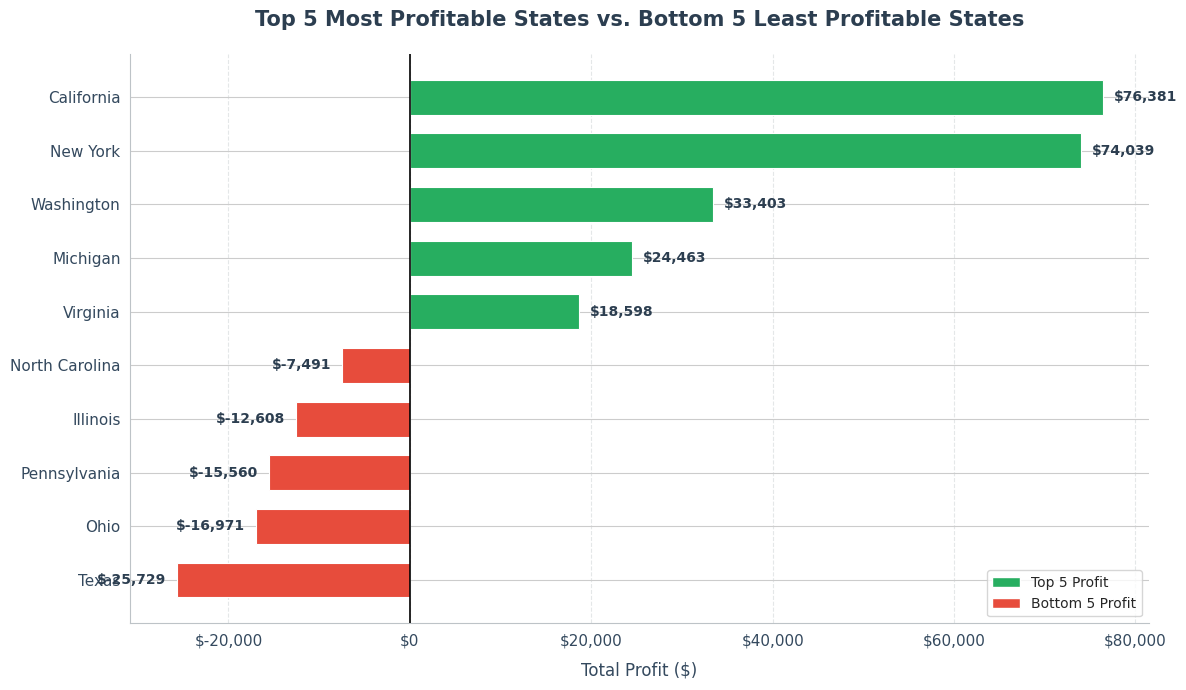

In [139]:
# ── Data Preparation ──────────────────────────────────────────────
state_profit = (
    df.groupby("state", observed=True)
      .agg(
          total_profit=("profit", "sum"),
          total_sales=("sales", "sum"),
          total_orders=("order_id", "nunique"),
          avg_profit=("profit", "mean")
      )
      .reset_index()
)

top5    = state_profit.nlargest(5, "total_profit")
bottom5 = state_profit.nsmallest(5, "total_profit")

# Combine and tag
state_chart = pd.concat([
    top5.assign(Group="Top 5 Profit"),
    bottom5.assign(Group="Bottom 5 Profit")
])

# Sort so most profitable sits at top of chart
state_chart = state_chart.sort_values("total_profit", ascending=True)

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

# Color mapping: green for profit, red for loss
colors = state_chart["total_profit"].apply(lambda x: "#27ae60" if x >= 0 else "#e74c3c")

bars = ax.barh(
    state_chart["state"],
    state_chart["total_profit"],
    color=colors,
    edgecolor="white",
    linewidth=0.8,
    height=0.65
)

# Zero-reference line
ax.axvline(0, color="black", linewidth=1.2, linestyle="-", zorder=3)

# Value labels on bars
for bar, value in zip(bars, state_chart["total_profit"]):
    x_pos = value
    ha = "left" if value >= 0 else "right"
    offset = 1200 if value >= 0 else -1200
    ax.text(
        x_pos + offset,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.0f}",
        va="center",
        ha=ha,
        fontsize=10,
        fontweight="bold",
        color="#2c3e50"
    )

# X-axis currency formatting
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
)

# Title and labels
ax.set_title(
    "Top 5 Most Profitable States vs. Bottom 5 Least Profitable States",
    fontsize=15,
    fontweight="bold",
    pad=20,
    color="#2c3e50"
)
ax.set_xlabel("Total Profit ($)", fontsize=12, labelpad=10, color="#34495e")
ax.set_ylabel("")

# Legend
legend_elements = [
    Patch(facecolor="#27ae60", edgecolor="white", label="Top 5 Profit"),
    Patch(facecolor="#e74c3c", edgecolor="white", label="Bottom 5 Profit")
]
ax.legend(
    handles=legend_elements,
    loc="lower right",
    frameon=True,
    fancybox=True,
    fontsize=10
)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#bdc3c7")
ax.spines["bottom"].set_color("#bdc3c7")
ax.tick_params(colors="#34495e", labelsize=11)

# Grid
ax.xaxis.grid(True, linestyle="--", alpha=0.4, color="#bdc3c7")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

**Interpretation:** California and New York dominate profitability, likely due to high sales volume in major metropolitan areas. Conversely, states like Texas and Ohio show significant losses, suggesting either excessive discounting, high return rates, or unfavorable cost structures in those markets. The business should investigate loss-making states to determine whether the issue is pricing, product mix, or operational costs.

## Visualization 2: How Are Sales Distributed Across States?

**Business Question:** Where is the company's revenue concentrated geographically?

**Approach:** Use a choropleth map to visualize total sales across all U.S. states.

In [140]:
# State abbreviation mapping for the map
state_abbrev = {
    'Alabama':'AL', 'Arizona':'AZ', 'Arkansas':'AR', 'California':'CA',
    'Colorado':'CO', 'Connecticut':'CT', 'Delaware':'DE', 'District of Columbia':'DC',
    'Florida':'FL', 'Georgia':'GA', 'Idaho':'ID', 'Illinois':'IL', 'Indiana':'IN',
    'Iowa':'IA', 'Kansas':'KS', 'Kentucky':'KY', 'Louisiana':'LA', 'Maine':'ME',
    'Maryland':'MD', 'Massachusetts':'MA', 'Michigan':'MI', 'Minnesota':'MN',
    'Mississippi':'MS', 'Missouri':'MO', 'Montana':'MT', 'Nebraska':'NE', 'Nevada':'NV',
    'New Hampshire':'NH', 'New Jersey':'NJ', 'New Mexico':'NM', 'New York':'NY',
    'North Carolina':'NC', 'North Dakota':'ND', 'Ohio':'OH', 'Oklahoma':'OK',
    'Oregon':'OR', 'Pennsylvania':'PA', 'Rhode Island':'RI', 'South Carolina':'SC',
    'South Dakota':'SD', 'Tennessee':'TN', 'Texas':'TX', 'Utah':'UT', 'Vermont':'VT',
    'Virginia':'VA', 'Washington':'WA', 'West Virginia':'WV', 'Wisconsin':'WI',
    'Wyoming':'WY'
}

state_profit["state_code"] = state_profit["state"].map(state_abbrev)

# Choropleth map: SALES distribution
fig = px.choropleth(
    state_profit,
    locations="state_code",
    locationmode="USA-states",
    color="total_sales",  # <-- FIXED: was total_profit
    scope="usa",
    hover_name="state",
    hover_data={
        "total_sales": ":,.0f",
        "total_profit": ":,.0f",
        "total_orders": True,
        "state_code": False
    },
    color_continuous_scale="Blues",
    labels={"total_sales": "Total Sales ($)"},
    title="Sales Distribution Across States"
)

fig.update_layout(
    title_x=0.5,
    geo=dict(bgcolor="rgba(0,0,0,0)")
)

fig.show()

**Interpretation:** Sales are heavily concentrated on the coasts — particularly California, New York, and Texas. The Midwest and Mountain regions show comparatively lower sales volumes. This geographic concentration represents both a strength (established markets) and a risk (over-dependence on a few states). The company may benefit from targeted marketing or distribution expansion in underperforming regions.

## Visualization 3: How Does Average Profit and Discount Vary by Region?

**Business Question:** Do regions with higher discount rates suffer from lower profitability?

**Approach:** Create a dual-axis chart comparing average profit (bars) against average discount (line) for each region.

In [141]:
region_performance = (
    df.groupby('region', observed=True)
      .agg(
          avg_profit=('profit', 'mean'),
          avg_discount=('discount', 'mean')
      )
      .reset_index()
)

fig = go.Figure()

# Bar chart: Average Profit
fig.add_trace(
    go.Bar(
        x=region_performance['region'],
        y=region_performance['avg_profit'],
        name='Average Profit',
        text=region_performance['avg_profit'].map('${:,.2f}'.format),
        textposition='outside',
        marker_color='steelblue'
    )
)

# Line chart: Average Discount
fig.add_trace(
    go.Scatter(
        x=region_performance['region'],
        y=region_performance['avg_discount'],
        name='Average Discount',
        mode='lines+markers+text',
        text=region_performance['avg_discount'].map('{:.1%}'.format),
        textposition='top center',
        yaxis='y2',
        line=dict(color='darkorange', width=3)
    )
)

fig.update_layout(
    title='Average Profit and Average Discount by Region',
    title_x=0.5,
    xaxis_title='Region',
    yaxis=dict(title='Average Profit ($)'),
    yaxis2=dict(
        title='Average Discount',
        tickformat='.0%',
        overlaying='y',
        side='right'
    ),
    legend_title='Metric',
    height=500
)

fig.show()

**Interpretation:** The Central region shows the highest average discount rate and the lowest average profit — a clear negative correlation. In contrast, the West and East regions maintain higher profitability with more restrained discounting. This suggests that aggressive discounting in the Central region is eroding margins. The business should review pricing strategy in that region and consider shifting from volume-based discounting to value-based selling.

## Visualization 4: Which Products Have the Highest Sales Volume?

**Business Question:** Which individual products are driving the most unit sales?

**Approach:** Rank products by total quantity sold and visualize the top 10.

/tmp/ipykernel_910/2147211906.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




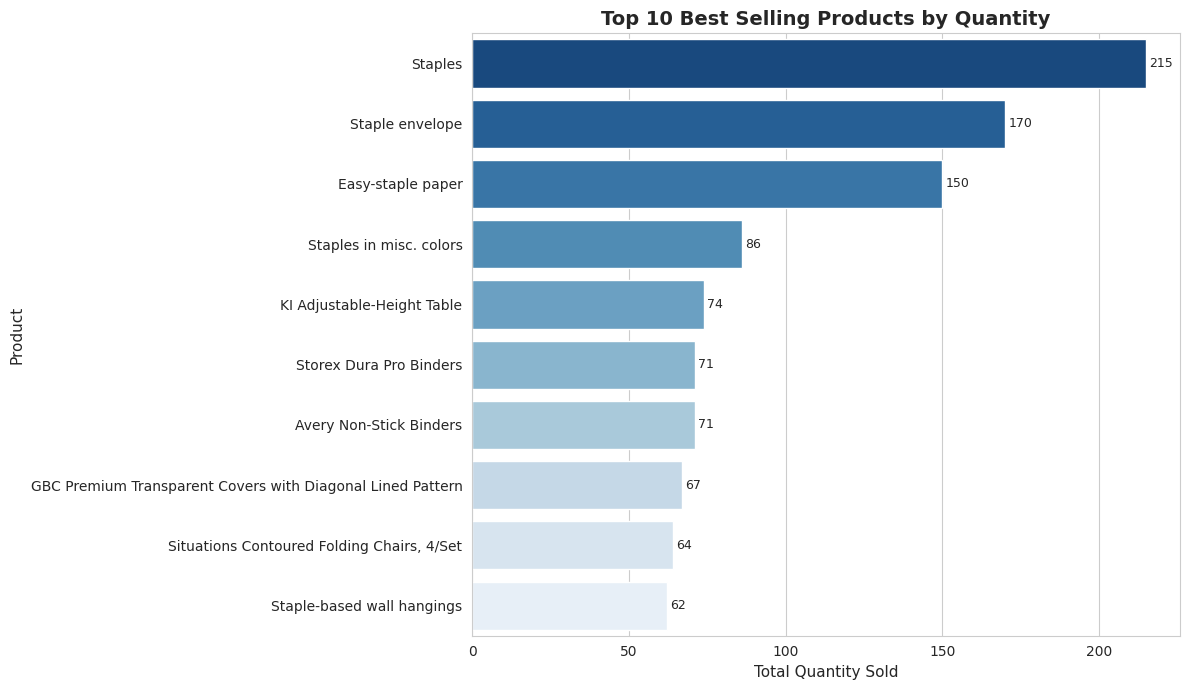

In [142]:
top10_products = (
    df.groupby('product_name', observed=True)
      .agg(total_quantity=('quantity', 'sum'))
      .reset_index()
      .sort_values('total_quantity', ascending=False)
      .head(10)
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top10_products,
    x="total_quantity",
    y="product_name",
    palette="Blues_r"
)

plt.title("Top 10 Best Selling Products by Quantity", fontsize=14, fontweight='bold')
plt.xlabel("Total Quantity Sold", fontsize=11)
plt.ylabel("Product", fontsize=11)

# Add value labels
for i, v in enumerate(top10_products['total_quantity']):
    plt.text(v + 1, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Interpretation:** Office supplies — particularly staples, envelopes, and fasteners — dominate unit sales. These are low-cost, high-frequency consumables that likely drive repeat purchases. While they may have lower individual margins, their volume makes them critical for customer retention and order frequency. The business should ensure these items are always well-stocked and consider bundling them with higher-margin products.

## Visualization 5: Which Products Generate the Highest Profit and the Greatest Loss?

**Business Question:** At the individual product level, which items are the biggest money-makers and which are the biggest money-losers?

**Approach:** Aggregate total profit by product name and visualize the top 5 most profitable and bottom 5 least profitable products.

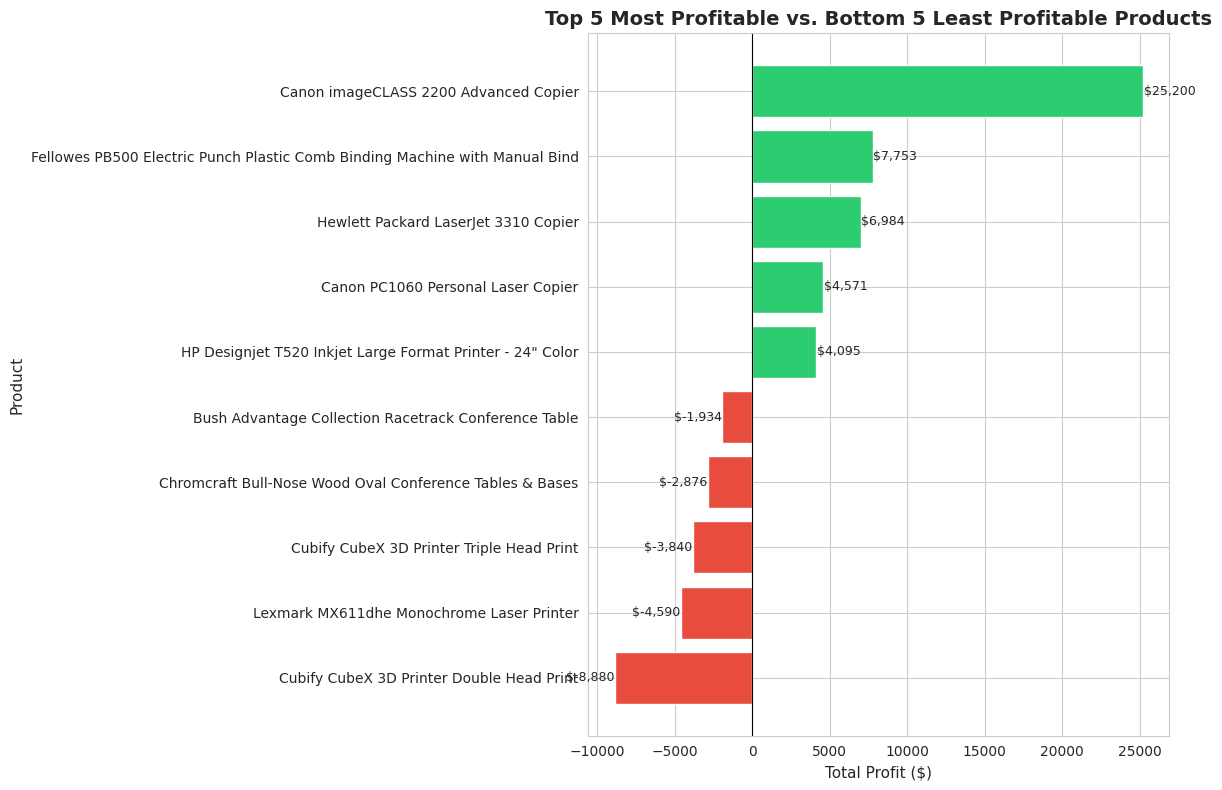

In [143]:
product_profit = df.groupby('product_name', observed=True).agg(total_profit=('profit', 'sum'), total_sales=('sales', 'sum'), total_quantity=('quantity', 'sum')).reset_index()
top5_products = product_profit.nlargest(5, 'total_profit')
bottom5_products = product_profit.nsmallest(5, 'total_profit')
combined_products = pd.concat([top5_products, bottom5_products]).sort_values('total_profit')
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in combined_products['total_profit']]
plt.figure(figsize=(12, 8))
bars = plt.barh(combined_products['product_name'], combined_products['total_profit'], color=colors)
plt.title("Top 5 Most Profitable vs. Bottom 5 Least Profitable Products", fontsize=14, fontweight='bold')
plt.xlabel("Total Profit ($)", fontsize=11)
plt.ylabel("Product", fontsize=11)
for bar in bars:
    value = bar.get_width()
    plt.text(value + (50 if value >= 0 else -50), bar.get_y() + bar.get_height()/2, f'${value:,.0f}', va='center', ha='left' if value >= 0 else 'right', fontsize=9)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

**Interpretation:** High-tech products like copiers and phones generate the largest absolute profits, likely due to high price points and strong demand. On the flip side, certain furniture items (particularly bookcases and tables) and office machines show substantial losses. These loss-making products may be heavily discounted, have high return rates, or suffer from supply chain cost issues. The business should evaluate whether to discontinue unprofitable SKUs, renegotiate supplier costs, or adjust pricing.

## Visualization 6: BCG Matrix — Which Sub-Categories Are Stars, Hidden Gems, Question Marks, and Bleeding Products?

**Business Question:** How do product sub-categories perform when evaluated by both sales volume and profit margin?

**Approach:** Use a BCG-style matrix with median sales as the vertical cutoff and 10% profit margin as the horizontal cutoff.

In [144]:
# Aggregate by category and sub-category
product_matrix = (
    df.groupby(['category', 'sub_category'], observed=True)
      .agg(
          total_sales=('sales', 'sum'),
          total_profit=('profit', 'sum'),
          total_quantity=('quantity', 'sum'),
          avg_discount=('discount', 'mean')
      )
      .reset_index()
)

# Calculate derived metrics
product_matrix['profit_margin'] = (product_matrix['total_profit'] / product_matrix['total_sales']) * 100
product_matrix['avg_discount'] = product_matrix['avg_discount'] * 100

# Define quadrant thresholds
sales_median = product_matrix['total_sales'].median()
margin_target = 10.0

# Classification function
def classify_quadrant(row):
    if row['total_sales'] >= sales_median and row['profit_margin'] >= margin_target:
        return 'Star Products'
    elif row['total_sales'] < sales_median and row['profit_margin'] >= margin_target:
        return 'Hidden Gems'
    elif row['total_sales'] < sales_median and row['profit_margin'] < margin_target:
        return 'Question Marks'
    else:
        return 'Bleeding Products'

product_matrix['bcg_category'] = product_matrix.apply(classify_quadrant, axis=1)

# Sort for display
product_matrix = product_matrix.sort_values(['bcg_category', 'total_sales'], ascending=[True, False])

# Display formatted table
display_table = product_matrix[[
    'bcg_category', 'category', 'sub_category', 'total_sales',
    'total_profit', 'profit_margin', 'avg_discount'
]].copy()

display_table['total_sales'] = display_table['total_sales'].map('${:,.2f}'.format)
display_table['total_profit'] = display_table['total_profit'].map('${:,.2f}'.format)
display_table['profit_margin'] = display_table['profit_margin'].map('{:.2f}%'.format)
display_table['avg_discount'] = display_table['avg_discount'].map('{:.1f}%'.format)

display(display_table.reset_index(drop=True))

,bcg_category,category,sub_category,total_sales,total_profit,profit_margin,avg_discount
0,Bleeding Products,Furniture,Chairs,"$328,449.10","$26,590.17",8.10%,17.0%
1,Bleeding Products,Office Supplies,Storage,"$223,843.61","$21,278.83",9.51%,7.5%
2,Bleeding Products,Furniture,Tables,"$206,965.53","$-17,725.48",-8.56%,26.1%
3,Bleeding Products,Technology,Machines,"$189,238.63","$3,384.76",1.79%,30.6%
4,Bleeding Products,Furniture,Bookcases,"$114,880.00","$-3,472.56",-3.02%,21.1%
5,Hidden Gems,Office Supplies,Appliances,"$107,532.16","$18,138.01",16.87%,16.7%
6,Hidden Gems,Furniture,Furnishings,"$91,705.16","$13,059.14",14.24%,13.8%
7,Hidden Gems,Office Supplies,Paper,"$78,479.21","$34,053.57",43.39%,7.5%
8,Hidden Gems,Office Supplies,Art,"$27,118.79","$6,527.79",24.07%,7.5%
9,Hidden Gems,Office Supplies,Envelopes,"$16,476.40","$6,964.18",42.27%,8.0%


In [145]:
# BCG Scatter Plot
fig = px.scatter(
    product_matrix,
    x='total_sales',
    y='profit_margin',
    text='sub_category',
    size='avg_discount',
    color='bcg_category',
    hover_data={
        'category': True,
        'total_sales': ':$,.2f',
        'total_profit': ':$,.2f',
        'profit_margin': ':.2f',
        'avg_discount': ':.1f',
        'bcg_category': True
    },
    title='BCG Product Analysis: Sales vs. Profit Margin',
    labels={
        'total_sales': 'Total Sales ($)',
        'profit_margin': 'Profit Margin (%)',
        'avg_discount': 'Avg Discount (%)'
    }
)

# Cutoff lines
fig.add_vline(x=sales_median, line_dash='dash', line_color='gray')
fig.add_hline(y=margin_target, line_dash='dash', line_color='gray')

# Styling
fig.update_traces(textposition='top center', textfont=dict(size=17))
x_min, x_max = product_matrix['total_sales'].min(), product_matrix['total_sales'].max()
y_min, y_max = product_matrix['profit_margin'].min(), product_matrix['profit_margin'].max()

# Quadrant labels
fig.add_annotation(x=(sales_median + x_max)/2, y=(margin_target + y_max)/2,
                   text='<b>STAR PRODUCTS</b><br>High Sales + High Margin',
                   showarrow=False, font=dict(size=12), bgcolor='white', bordercolor='green', borderwidth=1)
fig.add_annotation(x=(x_min + sales_median)/2, y=(margin_target + y_max)/2,
                   text='<b>HIDDEN GEMS</b><br>Low Sales + High Margin',
                   showarrow=False, font=dict(size=12), bgcolor='white', bordercolor='blue', borderwidth=1)
fig.add_annotation(x=(x_min + sales_median)/11, y=(y_min + margin_target)/2,
                   text='<b>QUESTION MARKS</b><br>Low Sales + Low Margin',
                   showarrow=False, font=dict(size=12), bgcolor='white', bordercolor='orange', borderwidth=1)
fig.add_annotation(x=(sales_median + x_max)/2, y=(y_min + margin_target)/2,
                   text='<b>BLEEDING PRODUCTS</b><br>High Sales + Low Margin',
                   showarrow=False, font=dict(size=12), bgcolor='white', bordercolor='red', borderwidth=1)

fig.update_layout(showlegend=False, xaxis_tickprefix='$', xaxis_tickformat=',.0f', height=600)
fig.show()

**Interpretation:**
- **Star Products (High Sales, High Margin):** Copiers and Phones are the stars — they generate significant revenue while maintaining healthy margins. These should be protected and promoted.
- **Hidden Gems (Low Sales, High Margin):** Items like Labels and Envelopes have excellent margins but lower sales volume. These represent opportunities for growth through increased marketing or bundling.
- **Bleeding Products (High Sales, Low Margin):** Tables and Bookcases sell well but destroy profitability through heavy discounting. The business must either raise prices, reduce costs, or deprioritize these categories.
- **Question Marks (Low Sales, Low Margin):** Fasteners and Supplies struggle on both fronts. These may need to be discontinued unless strategic value (e.g., driving store traffic) justifies keeping them.

## Visualization 7: How Do Sales and Profit Change Over Time?

**Business Question:** What are the seasonal and trend patterns in the company's financial performance?

**Approach:** Aggregate sales and profit by month and visualize both metrics on a dual-axis chart.

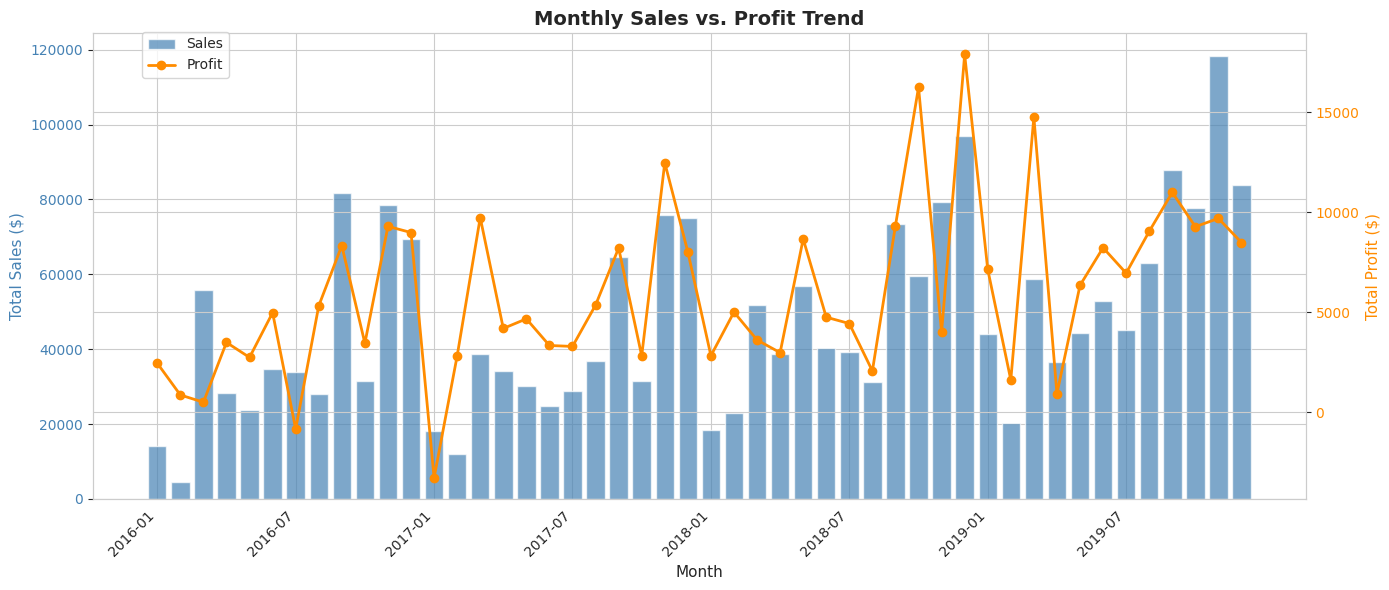

In [146]:
df['month'] = df['order_date'].dt.to_period('M').astype(str)

monthly_performance = (
    df.groupby('month', observed=True)
      .agg(
          total_sales=('sales', 'sum'),
          total_profit=('profit', 'sum')
      )
      .reset_index()
)

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(
    monthly_performance['month'],
    monthly_performance['total_sales'],
    color='steelblue',
    alpha=0.7,
    label='Sales'
)

ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('Total Sales ($)', fontsize=11, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax1.set_xticks(range(0, len(monthly_performance), 6))
ax1.set_xticklabels(
    monthly_performance['month'].iloc[::6],
    rotation=45,
    ha='right'
)

ax2 = ax1.twinx()

ax2.plot(
    monthly_performance['month'],
    monthly_performance['total_profit'],
    color='darkorange',
    marker='o',
    linewidth=2,
    label='Profit'
)

ax2.set_ylabel('Total Profit ($)', fontsize=11, color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title(
    'Monthly Sales vs. Profit Trend',
    fontsize=14,
    fontweight='bold'
)

fig.legend(
    loc='upper left',
    bbox_to_anchor=(0.1, 0.95)
)

plt.tight_layout()
plt.show()

**Interpretation:** Sales and profit generally move together, with noticeable peaks in late summer and end-of-year holiday seasons. However, there are months where sales remain high while profit dips — indicating periods of heavy promotional discounting. The business should plan inventory and marketing spend around these seasonal peaks while protecting margins during high-traffic months.

## Visualization 8: Which Sub-Categories Generate the Highest Sales?

**Business Question:** Which product categories contribute the most to total revenue?

**Approach:** Rank sub-categories by total sales and display as a horizontal bar chart.

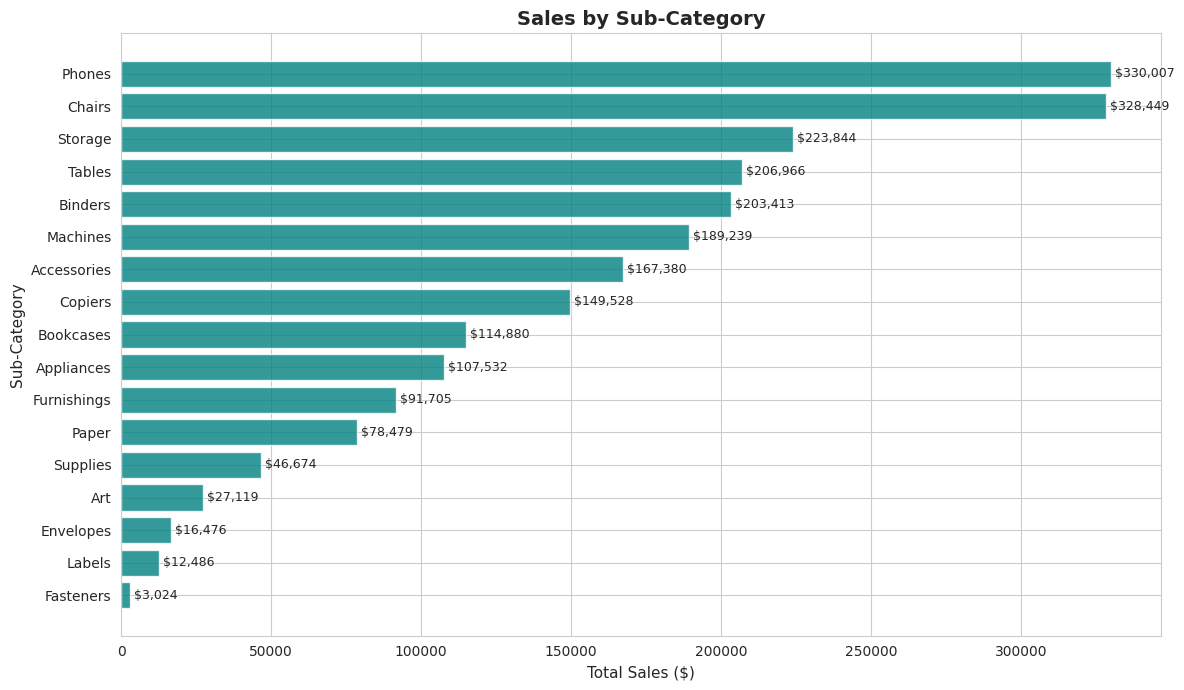

In [147]:
subcat_sales = (
    df.groupby('sub_category', observed=True)
      .agg(total_sales=('sales', 'sum'))
      .reset_index()
      .sort_values('total_sales', ascending=True)
)

plt.figure(figsize=(12, 7))
bars = plt.barh(subcat_sales['sub_category'], subcat_sales['total_sales'],
                color='teal', alpha=0.8)

plt.title('Sales by Sub-Category', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)', fontsize=11)
plt.ylabel('Sub-Category', fontsize=11)

# Add value labels
for bar in bars:
    value = bar.get_width()
    plt.text(value, bar.get_y() + bar.get_height()/2,
             f' ${value:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Interpretation:** Phones, Chairs, and Storage drive the majority of revenue. These are high-ticket items in the Technology and Furniture categories. Interestingly, high-sales categories do not always align with high-profit categories (as seen in the BCG matrix), which reinforces the need to evaluate performance using both metrics rather than sales alone.

## Supplementary Analysis 1: Correlation Matrix

**Business Question:** What relationships exist between the numerical variables, and which pairs are strongly correlated?

**Approach:** Compute the Pearson correlation matrix for key numerical features.

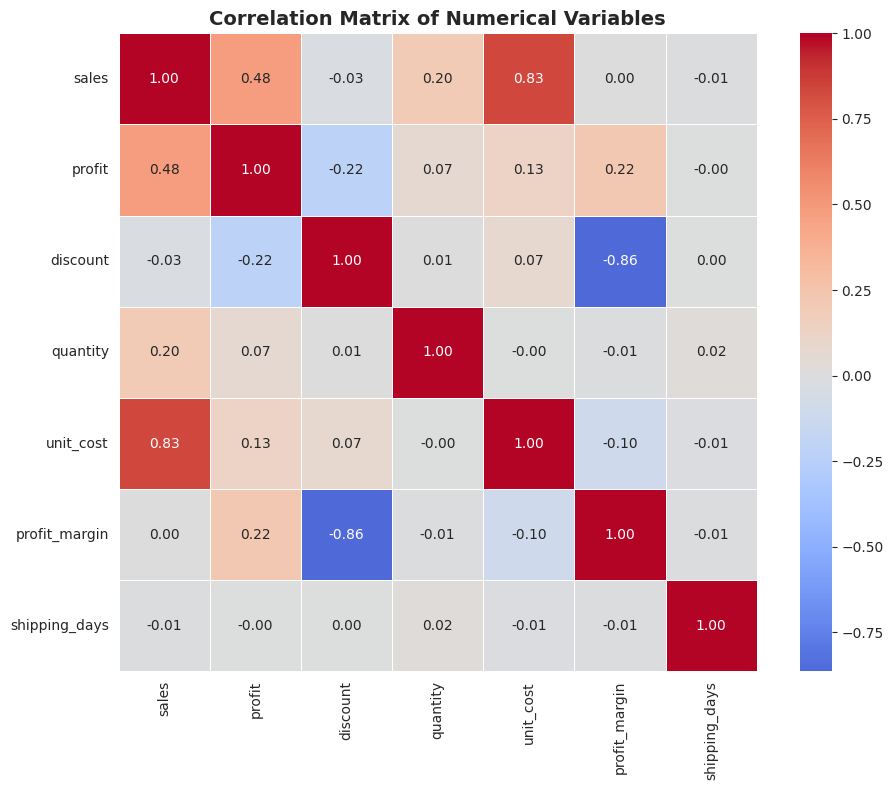

In [148]:
correlation_data = df[[
    'sales', 'profit', 'discount', 'quantity',
    'unit_cost', 'profit_margin', 'shipping_days'
]]

correlation_matrix = correlation_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)

plt.title('Correlation Matrix of Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** Sales and profit show a strong positive correlation, which is expected. More importantly, **discount shows a strong negative correlation with profit and profit margin** — confirming that heavy discounting directly hurts profitability. There is also a notable correlation between quantity and sales. Shipping days appear relatively independent of financial metrics, suggesting that delivery speed does not significantly impact profitability in this dataset.

## Supplementary Analysis 2: Order Fulfillment Performance

**Business Question:** What percentage of orders are fulfilled on time versus late based on the expected fulfillment time for each shipping mode?

**Approach:** Calculate the fulfillment time for each order, compare it with the expected fulfillment time for its shipping mode, and visualize the proportion of **On Time** and **Late** orders using a donut chart.

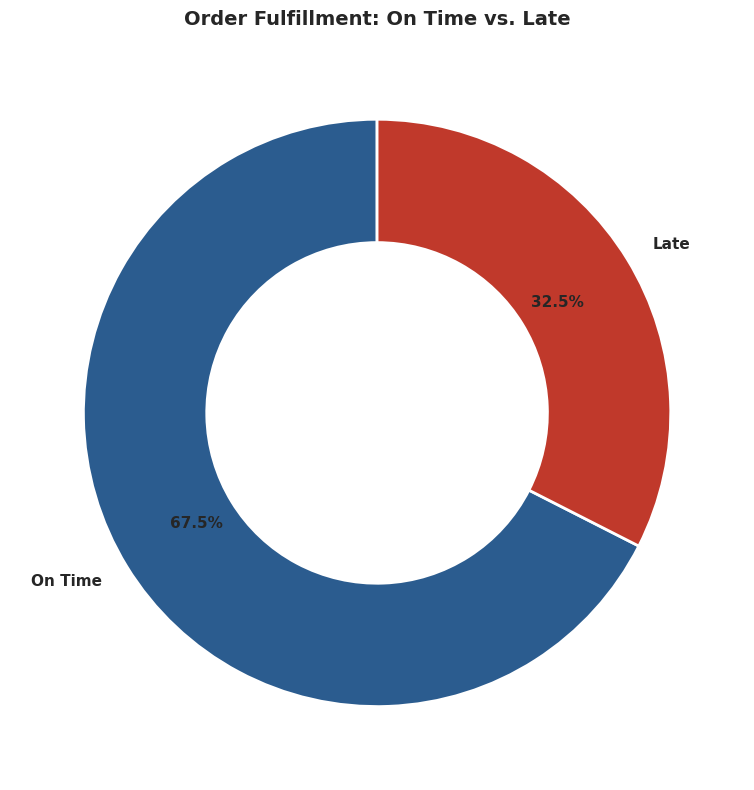

In [149]:
df['fulfillment_days'] = (df['ship_date'] - df['order_date']).dt.days
sla_rules = {'Same Day': 1, 'First Class': 2, 'Second Class': 3, 'Standard Class': 5}
df['sla_days'] = df['ship_mode'].map(sla_rules)
df['sla_status'] = df.apply(lambda row: 'On Time' if row['fulfillment_days'] <= row['sla_days'] else 'Late', axis=1)
sla_counts = df['sla_status'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(sla_counts, labels=sla_counts.index, autopct='%1.1f%%', startangle=90, pctdistance=0.72, wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2), colors=['#2b5c8f','#c0392b'], textprops={'fontsize':11,'fontweight':'bold'})
plt.title('Order Fulfillment: On Time vs. Late', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Interpretation:** The majority of orders are fulfilled within the expected time for their selected shipping mode, while a smaller proportion are classified as late. This indicates that overall fulfillment performance is relatively reliable, but the late orders highlight opportunities to improve shipping operations and maintain consistent delivery performance across all shipping modes.

# Business Insights

This section translates the visualizations into actionable business intelligence.

### 1. Geographic Performance
- **Strengths:** California and New York are powerhouse markets with both high sales and high profits.
- **Risks:** Texas and Ohio are significant loss centers. The Central region specifically suffers from excessive discounting that erodes margins.
- **Action:** Investigate state-level pricing strategies. Reduce discounting in the Central region and consider targeted promotions rather than blanket discounts.

### 2. Product Portfolio
- **Stars:** Copiers and Phones deliver both volume and margin. These should remain core to the product strategy.
- **Bleeding Products:** Tables and Bookcases in the Furniture category generate sales but destroy profit through discounting. The business must either renegotiate supplier costs or raise prices.
- **Hidden Gems:** Labels and Envelopes have excellent margins but low visibility. Increased marketing or bundling with high-volume items could unlock growth.

### 3. Discounting Strategy
- The correlation analysis and regional analysis both confirm that **discounting is the primary driver of profit erosion**.
- The Central region has the highest average discount and the lowest average profit — a direct causal relationship.
- **Action:** Implement margin guardrails. Restrict discount authority and train sales teams on value-based selling rather than competing on price.

### 4. Seasonality
- Sales and profit peak in late summer and year-end holidays.
- **Action:** Align inventory procurement and marketing budgets with these seasonal peaks. Avoid deep discounting during already-profitable high-traffic periods.

### 5. Operational Efficiency
- Shipping mode distribution shows customer preference for cost-effective Standard Class delivery.
- Shipping duration does not correlate strongly with profitability, suggesting that fulfillment speed is not a critical profit lever in this dataset.
- **Action:** Prioritize cost-efficient logistics over speed for the majority of orders.

# Conclusion

This analysis of the Superstore Sales dataset reveals a business that is geographically concentrated, heavily reliant on a few product categories, and vulnerable to profit erosion from aggressive discounting.

**Key Takeaways:**

1. **Sales & Profit:** Revenue is strong on the coasts but undermined by loss-making states and regions. The company generates sufficient top-line sales but struggles to convert them to profit in certain markets.

2. **Products:** The product portfolio is unbalanced. Technology items (Phones, Copiers) are profitable stars, while Furniture (Tables, Bookcases) bleeds margin despite high sales volume. Office Supplies drive repeat traffic but require cross-selling to improve overall basket profitability.

3. **Regions:** The Central region is the weakest performer due to excessive discounting. The West and East maintain healthier margins. A state-by-state review of pricing and cost structures is urgently needed for loss-making markets.

4. **Customers/Orders:** Customers overwhelmingly prefer Standard Class shipping, indicating price sensitivity over speed. Order patterns show clear seasonality that the business can exploit with better inventory planning.

5. **Strategic Recommendation:** The most impactful lever for improving profitability is **discount control**. By tightening discount policies — especially in the Central region and on Furniture items — the business can protect margins without necessarily sacrificing volume. Additionally, investing in the "Hidden Gems" (high-margin, low-volume products) through bundling and targeted marketing offers a low-risk growth opportunity.

This structured analysis — from preprocessing and feature engineering through visualization to business interpretation — provides a data-driven foundation for strategic decision-making across sales, marketing, and operations.